# 67 - CNN on Shifted MNIST: the payoff

**Section:** CNNs | **Prereqs:** `CNNs/CNN_MNIST.ipynb` and `FNNs/ShiftedMNIST.ipynb` | **Next:** `CNNs/EMNIST.ipynb`

The direct answer to `FNNs/ShiftedMNIST.ipynb`. Same experiment - train on normal
digits, test on digits randomly rolled sideways - with a CNN instead of a
fully connected network.

| Model | Accuracy on shifted test set |
|---|---|
| FNN | collapses to near chance |
| CNN | holds up |

**Why.** A convolution applies the *same* kernel at every position. A stroke that
moves 8 pixels right activates the same kernel, just at a different location, and
pooling then discards much of that location information anyway. The FNN had a
separate weight per pixel position, so a shifted digit landed on weights that had
never seen it.

This is **translation equivariance** (the feature map shifts with the input) and,
after pooling and global average pooling, approximate **translation invariance**
(the classification does not change at all).

**Read this notebook as one half of a controlled experiment.** Everything except
the architecture matches `FNNs/ShiftedMNIST.ipynb`, and the architecture is the
whole explanation for the difference.

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

import torchvision
import torchvision.transforms as T

from torchsummary import summary

from sklearn.model_selection import train_test_split


In [82]:
# MNIST, unmodified.
raw_data_train = torchvision.datasets.MNIST(root='/data', train=True, download=True)
raw_data_test = torchvision.datasets.MNIST(root='/data', train=False, download=True)

In [83]:
# 90/10 train/validation split; tensors to the GPU.
device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_data , val_data , train_label, val_label = train_test_split(raw_data_train.data, raw_data_train.targets, test_size=0.10)

train_data = train_data.detach().clone().to(dtype=torch.float, device=device)
val_data = val_data.detach().clone().to(dtype=torch.float, device=device)

train_label = train_label.detach().clone().to(dtype=torch.long, device=device)
val_label = val_label.detach().clone().to(dtype=torch.long, device=device)

device

'cuda'

In [84]:
# A custom Dataset (see Convolution and transformations/Creating_Custom_DataLoaders)
# so a transform pipeline can run per sample, per epoch.
# The size guard uses any(...): it fires as soon as ONE tensor has a different
# length. all(...) would only fire when every tensor mismatched, which is not
# the condition you want to catch.
class MNIST_Dataset(Dataset):
    r"""Dataset wrapping tensors.

    Each sample will be retrieved by indexing tensors along the first dimension.

    Args:
        *tensors (Tensor): tensors that have the same size of the first dimension.
    """

    def __init__(self, tensors , transformations=None) -> None:
        if any(tensors[0].size(0) != tensor.size(0) for tensor in tensors):
            raise AssertionError("Size mismatch between tensors")
        self.tensors = tensors
        self.transformations = transformations

    def __getitem__(self, index):
      if self.transformations:
        X = self.transformations(self.tensors[0][index])
        Y = self.tensors[1][index]
        return (X,Y)
      else:
        return tuple(tensor[index] for tensor in self.tensors)

    def __len__(self) -> int:
        return self.tensors[0].size(0)

In [85]:
# Train and validation transform pipelines.
train_transformation = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor()
])

val_transformation = T.Compose([
    T.ToPILImage(),
    T.ToTensor()
])

train_transformation, val_transformation

(Compose(
     ToPILImage()
     RandomHorizontalFlip(p=0.5)
     ToTensor()
 ),
 Compose(
     ToPILImage()
     ToTensor()
 ))

In [86]:
# Loaders, batch 256.
train_dataset = MNIST_Dataset((train_data,train_label), train_transformation)
val_dataset = MNIST_Dataset((val_data,val_label), val_transformation)

bs = 256
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0])

In [87]:
# The CNN. Read the shape at each stage - this is the part to internalise:
#   input             (N, 1, 28, 28)
#   conv1 s=2 + pool  -> 64 channels, 7x7
#   conv2 s=1 + pool  -> 128 channels, 3x3
#   conv3 s=2 + pool  -> 256 channels, 1x1
#   gap               -> (N, 256, 1, 1)
#   view              -> (N, 256)   flatten for the Linear layers
#   fc1 -> out        -> (N, 10)
#
# Channels go UP (1 -> 64 -> 128 -> 256) while spatial size goes DOWN. That is
# the standard CNN shape: trade 'where' for 'what', ending with many abstract
# features at almost no spatial resolution.
#
# AdaptiveAvgPool2d((1,1)) averages each channel to a single number, so the
# flattened size is exactly out_channels no matter the input image size. That is
# what makes the model input-size independent, and it removes the hand-computed
# flatten size that breaks so many CNNs.

class MNIST_Model(nn.Module):

  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,64, kernel_size=3, padding=1,stride=2)   # 28 -> 14, then pool -> 7
    self.conv2 = nn.Conv2d(64,128,kernel_size=3, padding=1, stride=1)  # 7 -> 7, then pool -> 3
    self.conv3 = nn.Conv2d(128,256,kernel_size=3, padding=1, stride=2)

    self.gap = nn.AdaptiveAvgPool2d((1,1))

    self.fc1 = nn.Linear(256,64)
    self.out = nn.Linear(64,10)


    self.pool = nn.MaxPool2d(2,2)


  def forward(self, x):

    x = self.pool(F.relu((self.conv1(x))))

    x =  self.pool(F.relu((self.conv2(x))))

    x =  self.pool(F.relu((self.conv3(x))))

    x = self.gap(x)

    x = x.view(x.size(0), -1)

    x = F.relu(self.fc1(x))

    return self.out(x)

In [88]:
model = MNIST_Model().to(device)
model

MNIST_Model(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [89]:
summary(model , (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 14, 14]             640
         MaxPool2d-2             [-1, 64, 7, 7]               0
            Conv2d-3            [-1, 128, 7, 7]          73,856
         MaxPool2d-4            [-1, 128, 3, 3]               0
            Conv2d-5            [-1, 256, 2, 2]         295,168
         MaxPool2d-6            [-1, 256, 1, 1]               0
 AdaptiveAvgPool2d-7            [-1, 256, 1, 1]               0
            Linear-8                   [-1, 64]          16,448
            Linear-9                   [-1, 10]             650
Total params: 386,762
Trainable params: 386,762
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 1.48
Estimated Total Size (MB): 1.67
-------------------------------------------

In [90]:
# Shifting the train dataset.

for i in range(train_loader.dataset.tensors[0].shape[0]):

   img = train_loader.dataset.tensors[0][i,:]


   randomRollInt = np.random.randint(-10,11) # Creating random numbers to shift by

   imgS = torch.roll(img, randomRollInt, dims=1)


   train_loader.dataset.tensors[0][i,:] = imgS

In [91]:
# Training. One CNN-specific detail: x.to(device) inside the loop is required
# because ToPILImage in the transform pipeline moves the tensor back to CPU.
# SGD with lr=0.25 and momentum=0.9 - a high rate that works here because the
# gradients are small and well-conditioned.
# 50 epochs here rather than 25.
def train_model():

  model = MNIST_Model().to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 50
  optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.25,
    momentum=0.9,
    )


  losses = []
  train_acc = []
  val_acc = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      x = x.to(device) # ToPILimage takes it back to cpu
      y = y.to(device)
      yhat = model(x)

      loss = lossfunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [92]:
model, losses, train_acc, val_acc = train_model()

Epoch 0 | Loss : 1.8836 | Train Acc 32.33631134033203 | Val Acc : 54.78333282470703
Epoch 10 | Loss : 0.2225 | Train Acc 93.14360046386719 | Val Acc : 91.83333587646484
Epoch 20 | Loss : 0.1763 | Train Acc 94.65029907226562 | Val Acc : 93.5
Epoch 30 | Loss : 0.1618 | Train Acc 95.39620208740234 | Val Acc : 93.78333282470703
Epoch 40 | Loss : 0.1886 | Train Acc 94.84561157226562 | Val Acc : 93.06666564941406
Epoch 49 | Loss : 0.1909 | Train Acc 95.13764953613281 | Val Acc : 93.21666717529297


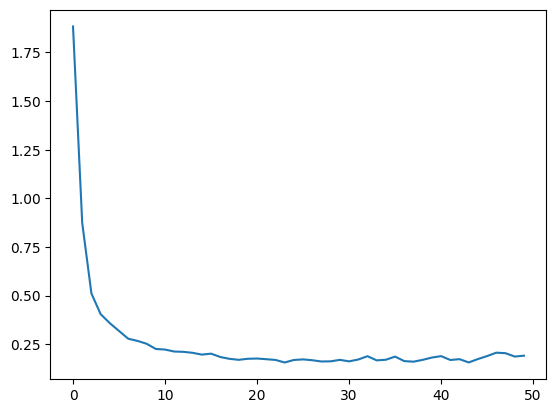

In [93]:
# Loss curve on the (unshifted) training data.
plt.plot(losses);

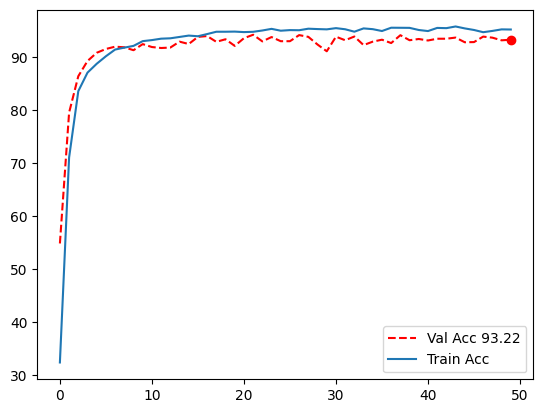

In [94]:
# Train and validation accuracy - both on unshifted images, so this is just the
# baseline before the interesting part.
plt.plot(val_acc, 'r--', label=f"Val Acc {val_acc[-1]:.2f}")
plt.plot(49,val_acc[-1], 'ro')
plt.plot(train_acc, label='Train Acc')
plt.legend();

## Testing

In [95]:
# The untouched test set.
test_data_tensor = raw_data_test.data.detach().clone().to(dtype=torch.float, device=device)
test_label_tensor = raw_data_test.targets.detach().clone().to(dtype=torch.long, device=device)


test_dataset = MNIST_Dataset((test_data_tensor, test_label_tensor), transformations=val_transformation)

In [96]:
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

In [97]:
# THE EXPERIMENT: roll every test image by a random -10..+10 pixels, exactly as
# FNNs/ShiftedMNIST.ipynb did.
# The training set is untouched, so the model has never seen a shifted digit.
# (dims=1 shifts along the second axis of the (28,28) image - its columns.)
for i in range(test_loader.dataset.tensors[0].shape[0]):

   img = test_loader.dataset.tensors[0][i,:]


   randomRollInt = np.random.randint(-10,11) # Creating random numbers to shift by

   imgS = torch.roll(img, randomRollInt, dims=1)


   test_loader.dataset.tensors[0][i,:] = imgS

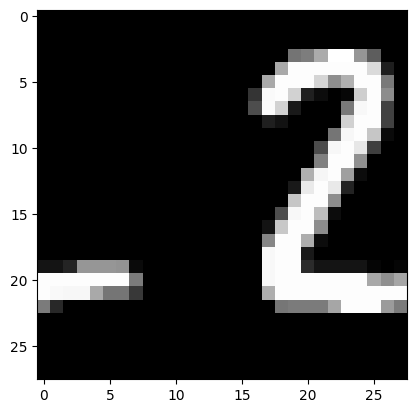

In [98]:
# One shifted digit, confirming the transformation was applied.
plt.imshow(test_loader.dataset.tensors[0][1,:].cpu(),cmap='gray')

In [99]:
# Evaluation on the shifted test set.
with torch.no_grad():
  model.eval()
  a, b = next(iter(test_loader))
  test_predictions = model(a.to(device))

  test_acc = 100 * torch.mean( (torch.argmax(test_predictions, dim=1) == b.to(device)).float().detach().cpu())


In [100]:
# The result. Compare directly with the FNN's number on the same experiment:
# the FNN fell to near chance, the CNN barely moves.
# Convolution's weight sharing is the entire reason.
test_acc

tensor(92.4100)

In [101]:
# Per-digit report on shifted data. Any digit that does degrade is usually one
# whose distinguishing stroke got rolled off the edge of the frame.
from sklearn.metrics import classification_report

preds = torch.argmax(test_predictions, dim=1).cpu().numpy()
true_labels = b.cpu().numpy()

print(classification_report(true_labels, preds, target_names=raw_data_test.classes))

              precision    recall  f1-score   support

    0 - zero       0.95      0.98      0.96       980
     1 - one       0.98      0.98      0.98      1135
     2 - two       0.85      0.91      0.88      1032
   3 - three       0.89      0.94      0.91      1010
    4 - four       0.94      0.95      0.94       982
    5 - five       0.92      0.81      0.86       892
     6 - six       0.95      0.92      0.93       958
   7 - seven       0.92      0.95      0.93      1028
   8 - eight       0.89      0.94      0.91       974
    9 - nine       0.96      0.86      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.92      0.92     10000



### CNNs perform well on shifted data too..
